<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [2]:
# !pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

In [3]:
# !pip install --ignore-installed huggingface-hub==0.20.3

In [4]:
# # После перезапуска ядра
# !pip uninstall huggingface-hub -y
# !pip install huggingface-hub==0.20.3

# # Проверка версии
# import huggingface_hub
# print(f"Installed version: {huggingface_hub.__version__}")

In [5]:
# !pip install --upgrade sentence-transformers

In [6]:
# !pip install pacmap

In [7]:
# !pip install -U bitsandbytes>=0.46.1

In [8]:
# !pip uninstall langchain-community -y
# !pip install langchain-community
# !pip install --upgrade sentence-transformers

In [9]:
# !pip install ragatouille

In [10]:
import warnings

# from huggingface_hub import hf_hub_download
# import huggingface_hub

# huggingface_hub.cached_download = hf_hub_download

warnings.filterwarnings('ignore')

import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain.docstore.document import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, AutoModelForSeq2SeqLM
# from ragatouille import RAGPretrainedModel
import os
import sys

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки
from langchain.text_splitter import RecursiveCharacterTextSplitter

from sklearn.feature_extraction.text import TfidfVectorizer
import re
import string
import nltk
import pymorphy2
from nltk.corpus import stopwords
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from FlagEmbedding import FlagReranker
import faiss
import gc
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import umap
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from transformers import Pipeline

pd.set_option('display.max_colwidth', 500)
pd.set_option('display.max_rows', 500)

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

Используется устройство: cuda


In [12]:
os.makedirs('content', exist_ok=True)

In [13]:
# !nvidia-smi

## Загрузка данных (4 балла)

In [14]:
# url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
# output = 'file.csv'

# gdown.download(url, output, quiet=False)

# data = pd.read_csv('file.csv')

In [15]:
# Загрузка данных

file_id = '1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'content/file.csv'

if not os.path.exists(output):
    gdown.download(id=file_id, output=output, quiet=False)

In [16]:
data = pd.read_csv(output).drop('Unnamed: 0', axis=1, errors='ignore')

In [17]:
# data.sample(500)
data.sample(3)

,Name,WikiData,City,Lon,Lat,description,image,en_txt
472,Серго Орджоникидзе,Q107506739,Екатеринбург,60.592449,56.885479,Памятник в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAE2AeADASIAAhEBAxEB/8QAHAAAAQQDAQAAAAAAAAAAAAAAAAMEBQYBAgcI/8QATRAAAgEDAwIDBQQHBAYJBAIDAQIDAAQRBRIhBjETQVEHImFxgRQykaEVI0JSscHRCDNi8BYXJCWT4TRDRFNygpKi8SZVY4MYNUVzsv/EABcBAQEBAQAAAAAAAAAAAAAAAAABAgP/xAAZEQEBAQEBAQAAAAAAAAAAAAAAARExIQL/2gAMAwEAAhEDEQA/AOAyyWhnilTe6J3fgBju8xz5eVdy...,arafed statue of a man holding a bird in front of a building
2531,улица Добролюбова,Q15954283,Екатеринбург,60.603180,56.834293,улица в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAFAAagDASIAAhEBAxEB/8QAHAAAAgMBAQEBAAAAAAAAAAAABAUCAwYAAQcI/8QASRAAAgEDAwICBwUGAwYFBAIDAQIDAAQRBRIhMUETUQYUImFxgZEjMqGxwRUzQlJi0XLh8QckU2OS8BY0Q4KyJXOTokRUlMLS/8QAGgEAAwEBAQEAAAAAAAAAAAAAAAECAwQFBv/EACsRAAICAgIBAwQCAgMBAAAAAAABAgMEESExEgUTQRQiMlFCYRVSI3GBM//aAAwDAQACEQMRAD8A/Uqa...,map of a city with a blue marker on it
10170,Надвратная церковь святого князя Александра Невского,NaN,Владимир,40.413509,56.131752,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBAUGBgUGCA4JCAcHCBEMDQoOFBEVFBMRExMWGB8bFhceFxMTGyUcHiAhIyMjFRomKSYiKR8iIyL/2wBDAQYGBggHCBAJCRAiFhMWIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiIiL/wAARCAE6AeADASIAAhEBAxEB/8QAHQAAAAcBAQEAAAAAAAAAAAAAAAECAwQFBgcICf/EAEgQAAIBAwMCBAMEBwcCBAUFAQECAwAEEQUSIQYxE0FRYQcicRQygZEIFSNCUqGxJDNicsHR8BaCFzRDkiWisuHxRXODo8LS/8QAGgEAAwEBAQEAAAAAAAAAAAAAAAECAwQFBv/EADURAAICAQQCAgAEBAILAAAAAAABAhEDBBIhMRNBBVEUIjJhFSORwXGhMzRCU2JjcoHR4fD/2gAMAwEA...,arafed view of a building with a clock tower in the background


In [18]:
data['City'].unique()

<ArrowStringArray>
['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль']
Length: 4, dtype: str

Проверим датасет на предмет пропусков

In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         14634 non-null  str    
 1   WikiData     12078 non-null  str    
 2   City         14634 non-null  str    
 3   Lon          14634 non-null  float64
 4   Lat          14634 non-null  float64
 5   description  12078 non-null  str    
 6   image        14634 non-null  str    
 7   en_txt       14634 non-null  str    
dtypes: float64(2), str(6)
memory usage: 641.0 MB


In [20]:
data.isna().sum()

Name              0
WikiData       2556
City              0
Lon               0
Lat               0
description    2556
image             0
en_txt            0
dtype: int64

Удалим строки с пропусками в WikiData и проверим датасет еще раз на предмет пропусков

In [21]:
data = data.dropna(subset=['WikiData'])

data.isna().sum()

Name           0
WikiData       0
City           0
Lon            0
Lat            0
description    0
image          0
en_txt         0
dtype: int64

In [22]:
# sorted(data['WikiData'].unique(), reverse=True)
# sorted(data['description'].unique(), reverse=False)
sorted(data['en_txt'].unique(), reverse=True)

['прррмомоннннннннннн',
 'yellow house with a black roof and a white fence',
 'yellow flowers in front of a brick building with a clock tower',
 'yellow church with blue domes and a clock tower in a city',
 'yellow church with a golden dome on a sunny day',
 'yellow church with a golden dome on a cloudy day',
 'yellow church with a golden dome and a steeple on a street corner',
 'yellow church with a golden dome and a cross on top',
 'yellow church with a blue dome and a cross on the front',
 'yellow bus parked in front of a large yellow building with a green roof',
 'yellow building with white trim and windows on a sunny day',
 'yellow building with white trim and windows on a street corner',
 'yellow building with white trim and windows in winter time',
 'yellow building with white trim and windows in snow covered area',
 'yellow building with white trim and windows and a sign on the front',
 'yellow building with white trim and windows',
 'yellow building with white trim and columns

In [ ]:
# В колонке 'en_txt' замечено значение 'прррмомоннннннннннн', заменим его на моду в соответсвии с полем Name

mask = data['en_txt'] == 'прррмомоннннннннннн'
name_field = data[mask]['Name'].iloc[0]
print(name_field)

mode_value = data[data['Name'] == name_field]['en_txt'].mode()[0]
print(mode_value)

data.loc[mask, 'en_txt'] = mode_value

Ярославский дворец молодёжи
there is a building with a sign on the top of it


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [24]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [25]:
def get_image(data):
    image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
    return image

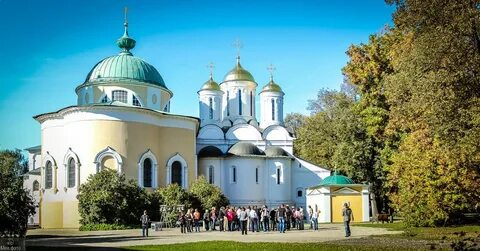

In [26]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - самое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

Проверим датасет на предмет пропусков

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

Вместо RAGatouille из ragatouille буду использорвать альтернативу (FlagReranker)

In [ ]:
# TF-IDF для выявления выбросов

# Создание TF‑IDF вектройзера (50 самых значимых слов, без стоп‑слов)
tfidf = TfidfVectorizer(lowercase=True, 
                        max_features=50, 
                        stop_words='english'
                        )

# Матрица для текстов в en_txt
tfidf_matrix = tfidf.fit_transform(data['en_txt'].fillna(''))

# Средний TF‑IDF скор для каждого описания
avg_tfidf = np.array(tfidf_matrix.mean(axis=1)).flatten()
data['tfidf_score'] = avg_tfidf

# Отсечение (100 - a)% текстов за наибольшим TF‑IDF скором
a = 95
threshold = np.percentile(avg_tfidf, a)
data['is_outlier'] = data['tfidf_score'] > threshold

clean_data = data[~data['is_outlier']].copy()

# Стратификация (выбор образцов: Город-Достопримечательность)
clean_data['group_key'] = clean_data['City'].astype(str) + '||' + clean_data['Name'].astype(str)

stratified_data = clean_data.groupby('group_key', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1), random_state=42)
).reset_index(drop=True)

if 'group_key' in stratified_data.columns:
    stratified_data = stratified_data.drop(columns=['group_key'])

# Ограничение до 100 записей
if len(stratified_data) > 100:
    stratified_data = stratified_data.sample(n=100, random_state=42)

print(f"Чистых записей: {len(clean_data)}")
print(f"Удалено выбросов: {data['is_outlier'].sum()}")
print(f"Итоговый размер выборки: {len(stratified_data)}")

Чистых записей: 11480
Удалено выбросов: 598
Итоговый размер выборки: 100


In [28]:
# # Создание обогащённого текста

# english_col = 'en_txt' if 'en_txt' in stratified_data.columns else 'englishText'

# stratified_data['fullText'] = (
#     stratified_data['Name'].fillna('').astype(str) + '. ' +
#     stratified_data['City'].fillna('').astype(str) + '. ' +
#     stratified_data['description'].fillna('').astype(str) + ' ' +
#     stratified_data[english_col].fillna('').astype(str)
# )

# stratified_data['fullText'] = stratified_data['fullText'].str.replace(r'\s+', ' ', regex=True).str.strip()

# print(f"\nПример обогащённого текста:")
# print(stratified_data['fullText'].iloc[0][:300] + "...")

In [29]:
# Создание обогащённого текста

stratified_data['fullText'] = (
    stratified_data['Name'].fillna('').astype(str) + '. ' +
    stratified_data['City'].fillna('').astype(str) + '. ' +
    stratified_data['description'].fillna('').astype(str) + ' ' +
    stratified_data['en_txt'].fillna('').astype(str)
)

stratified_data['fullText'] = stratified_data['fullText'].str.replace(r'\s+', ' ', regex=True).str.strip()

print(f'\nПример обогащённого текста:')
print(stratified_data['fullText'].iloc[0][:300] + '...')


Пример обогащённого текста:
Лицей № 82. Нижний Новгород. Лицей № 82 "Школа баррикад" arafed group of children in school uniforms standing on steps...


Настройка RAG

In [30]:
# Разбивка текста на чанки
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=100,
    separators=['\n\n', '\n', '. ', ' ', ''],
    length_function=len
)

document_texts = stratified_data['fullText'].tolist()
document_metadata = stratified_data[['Name', 'City', 'description', 
                                     'WikiData', 'Lon', 'Lat', 'image']].to_dict('records')

# Создание чанков
all_chunks = []
all_metadata = []

for text_index, current_text in enumerate(document_texts):
    if isinstance(current_text, str) and len(current_text) > 10:
        chunks = text_splitter.split_text(current_text)
        for text_chunk in chunks:
            all_chunks.append(text_chunk)
            all_metadata.append(document_metadata[text_index])

print(f'Создано {len(all_chunks)} чанков из {len(document_texts)} документов')

Создано 100 чанков из 100 документов


In [31]:
# Загрузка модели эмбеддингов

embedding_model = SentenceTransformer('intfloat/multilingual-e5-small')
embedding_model = embedding_model.to(device)
embedding_model.eval()

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)

In [32]:
# Создание эмбеддингов

chunk_embeddings = embedding_model.encode(
    all_chunks,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=32
)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [33]:
# Создание FAISS индекса

faiss_index = faiss.IndexFlatIP(chunk_embeddings.shape[1])
faiss_index.add(chunk_embeddings.astype('float32'))
print(f'Векторная база данных создана, размерность: {faiss_index.d}')

Векторная база данных создана, размерность: 384


In [34]:
# Функция поиска

def search_chunks_by_query(search_query, results_number=10):
    query_embedding = embedding_model.encode([search_query], normalize_embeddings=True)
    distance_scores, found_indices = faiss_index.search(query_embedding.astype('float32'), results_number)
    search_results = []
    for result_index, score_value in zip(found_indices[0], distance_scores[0]):
        search_results.append({
            'text': all_chunks[result_index],
            'metaData': all_metadata[result_index],
            'score': float(score_value)
        })
    return search_results

In [35]:
# Загрузка модели переранжировщика

os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
reranker_model = FlagReranker('BAAI/bge-reranker-large', use_fp16=True)

In [36]:
# Загрузка модели для генерации ответов

model_answer_name = 'Qwen/Qwen2.5-3B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(model_answer_name)
tokenizer.pad_token = tokenizer.eos_token

model_answer = AutoModelForCausalLM.from_pretrained(
    model_answer_name,
    torch_dtype=torch.float16,
    device_map='auto'
)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [37]:
# Функция формирования промпта

def make_prompt(data, question):
    main_res = data[0]
    other_res = data[1:]

    main_metadata = main_res['metadata']

    # Поля для промта
    name = main_metadata.get('Name', '')
    city = main_metadata.get('City', '')
    desc = main_metadata.get('description', '')
    wikidata = main_metadata.get('WikiData', '')
    lon = main_metadata.get('Lon', '')
    lat = main_metadata.get('Lat', '')
    
    main_context = f'''
    {name} находится в городе {city}. Это {desc}. Он расположен на широте {lat} и долготе {lon}.
    Более подробную информацию можно узнать на викидате, ID {name} - {wikidata}.
    '''
    
    other_data = []
    for x in other_res:
        name_other = x['metadata'].get('Name', '')
        city_other = x['metadata'].get('City', '')
        info = f'''{name_other} в городе {city_other}'''
        other_data.append(info)
    
    other_context = ' '.join(other_data)

    result_prompt = f'''
    <|im_start|>system
    Ты помощник туриста.
    <|im_end|>
    <|im_start|>user
    Контекст: {main_context}
    Дополнительные данные: {other_context}
    Вопрос: {question}

    Ответь на вопрос, используя только информацию из контекста. Сообщи естественным
    человеческим языком всё, что узнал из контекста об объекте, интересующем пользователя: 
    название, город, широту, долготу, викидату. Ты должен говорить как человек, 
    а не просто выдавать данные. Не придумывай информацию, которой нет в контексте. 
    Списки строго запрещены. Если вопрос никак не связан с контекстом, скажи "я не знаю". 
    В конце ответа напиши с новой строки: "Также вас могут заинтересовать:" и сообщи 
    обо всех объектах, которые перечислены в дополнительных данных.
    <|im_end|>
    <|im_start|>assistant
    '''
    return result_prompt, main_context, other_context

In [38]:
def retrieve_and_rerank(query, k=5, rerank_k=10):
    """
    Поиск релевантных чанков и их переранжирование
    """
    # Поиск релевантных чанков
    query_embedding = embedding_model.encode([query], normalize_embeddings=True)
    scores, indices = faiss_index.search(query_embedding.astype('float32'), rerank_k)
    
    # Сбор результатов
    initial_results = []
    for idx, score in zip(indices[0], scores[0]):
        if idx != -1:
            initial_results.append({
                'content': all_chunks[idx],
                'metadata': all_metadata[idx],
                'score': float(score)
            })
    
    # Переранжирование через FlagReranker
    passages = [res['content'] for res in initial_results]
    pairs = [[query, passage] for passage in passages]
    rerank_scores = reranker_model.compute_score(pairs)
    
    # Сортировка по скору
    for i, res in enumerate(initial_results):
        res['rerank_score'] = float(rerank_scores[i])
    
    initial_results.sort(key=lambda x: x['rerank_score'], reverse=True)
    
    # Формирование результата
    final_results = []
    for res in initial_results[:k]:
        final_results.append({
            'content': res['content'],
            'metadata': res['metadata']
        })
    
    return final_results

In [39]:
def get_answer(question, k=3):
    """
    Функция получения ответа
    """
    torch.cuda.empty_cache()
    results = retrieve_and_rerank(question, k=k)    
    prompt, main_context, other_context = make_prompt(results, question)
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model_answer.device)
    outputs = model_answer.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=True,
        temperature=0.2,
        pad_token_id=tokenizer.eos_token_id
    )
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    images = results[0]['metadata']['image'] 
    context = f'''
    Информация о самом релевантном объекте: {main_context}
    Дополнительно: {other_context}
    '''
    answer = full_text.split('assistant')[-1].strip()
    
    del inputs
    del outputs
    torch.cuda.empty_cache()
    
    return answer, context, images

In [40]:
def get_image(image_data):
    """
    Функция для декодирования изображений
    """
    missing_padding = len(image_data) % 4
    if missing_padding:
        image_data += '=' * (4 - missing_padding)
    image_bytes = base64.b64decode(image_data)
    end_position = image_bytes.rfind(b'\xff\xd9')
    if end_position > 0:
        image_bytes = image_bytes[:end_position + 2]
    image = Image.open(BytesIO(image_bytes)).convert('RGB')

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [41]:
# Подготовка данных для визуализации

has_city = stratified_data['City'].notna()
cities_data = stratified_data[has_city].copy()
sample_data = cities_data.sample(
    min(2000, len(cities_data)), random_state=42).copy()

sample_embeddings = np.array(embedding_model.encode(
    sample_data['fullText'].fillna('').tolist(),
    normalize_embeddings=False,
    show_progress_bar=True
))

city_names = sample_data['City'].tolist()

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

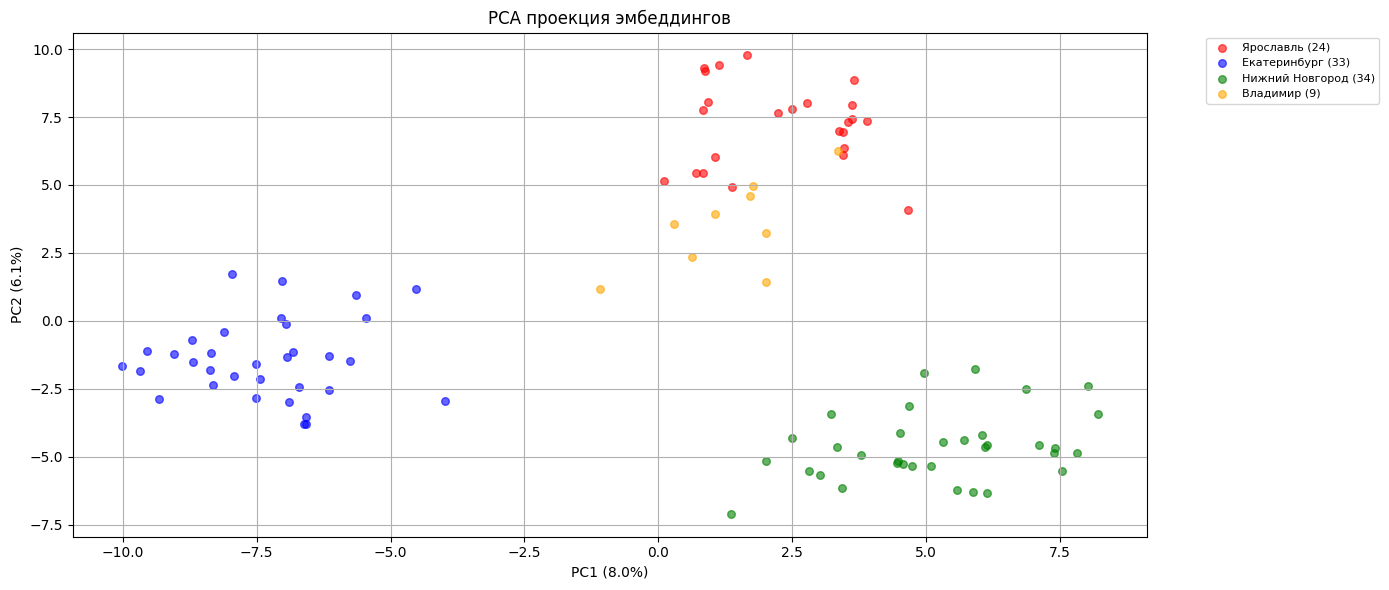

In [42]:
# PCA

scaler = StandardScaler()
sample_embeddings_scaled = scaler.fit_transform(sample_embeddings)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(sample_embeddings_scaled)
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(14, 6))

# plt.subplot(1, 2, 1)
cities = list(set(city_names))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for idx, city in enumerate(cities[:10]):
    mask = [item == city for item in city_names]
    if sum(mask) > 0:
        plt.scatter(
            pca_result[mask, 0],
            pca_result[mask, 1],
            label=f'{city} ({sum(mask)})',
            alpha=0.6,
            s=30,
            color=colors[idx % len(colors)]
        )

plt.title('PCA проекция эмбеддингов', fontsize=12)
plt.xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=10)
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid()

plt.tight_layout()

plt.show()

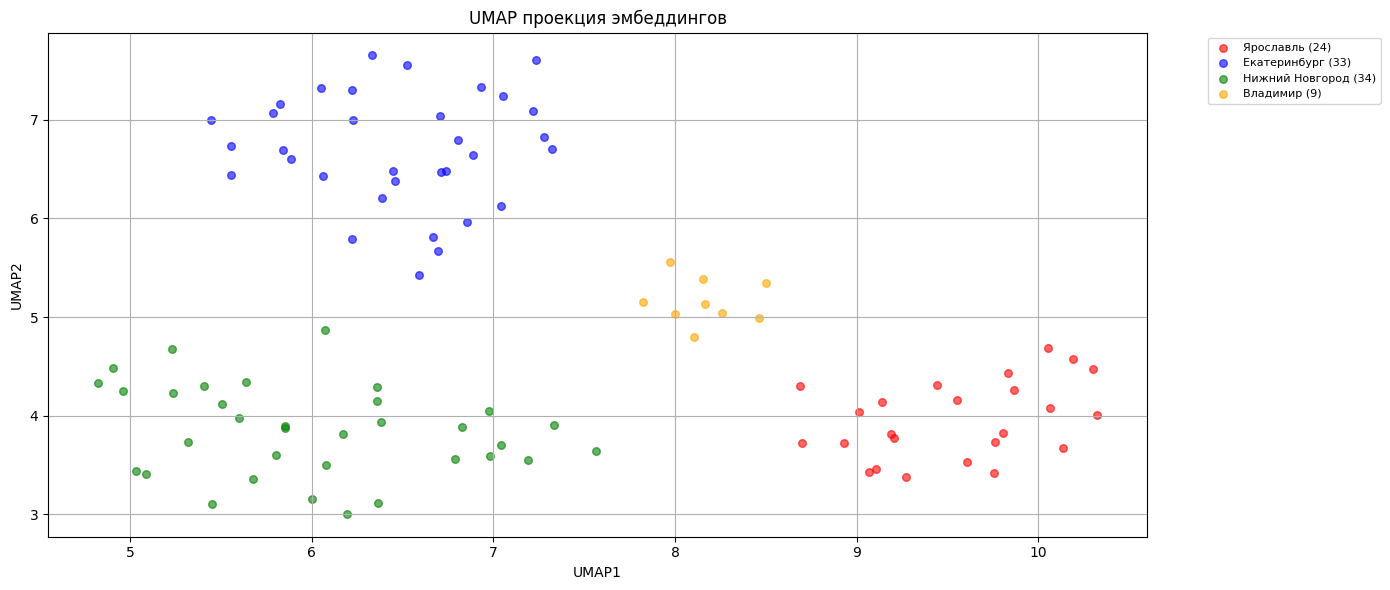

In [43]:
# UMAP

scaler_mm = MinMaxScaler()
sample_embeddings_mm = scaler_mm.fit_transform(sample_embeddings)

umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
umap_result = umap_reducer.fit_transform(sample_embeddings_mm)

plt.figure(figsize=(14, 6))
# plt.subplot(1, 2, 2)
for idx, city in enumerate(cities[:10]):
    mask = [item == city for item in city_names]
    if sum(mask) > 0:
        plt.scatter(
            umap_result[mask, 0],
            umap_result[mask, 1],
            label=f'{city} ({sum(mask)})',
            alpha=0.6,
            s=30,
            color=colors[idx % len(colors)]
        )

plt.title('UMAP проекция эмбеддингов', fontsize=12)
plt.xlabel('UMAP1', fontsize=10)
plt.ylabel('UMAP2', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid()

plt.tight_layout()

plt.show()

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [44]:
def answer_relevancy(question, answer, embedding_model, generated_questions=3):
    if not isinstance(question, str) or not isinstance(answer, str):
        return 0.0
    if len(question.strip()) == 0 or len(answer.strip()) == 0:
        return 0.0

    question_embedding = embedding_model.encode([question], normalize_embeddings=True)[0]
    
    answer_sentences = answer.split('. ')
    generated_questions_list = []

    for sentence in answer_sentences[:generated_questions]:
        if len(sentence) > 20:
            key_words = sentence.split()[:5]
            if key_words:
                generated_questions_list.append(f'Что такое {" ".join(key_words)}?')

    if not generated_questions_list:
        generated_questions_list = [question]

    similarity_scores = []
    for generated_question in generated_questions_list:
        g_embedding = embedding_model.encode([generated_question], normalize_embeddings=True)[0]
        similarity_scores.append(float(np.dot(question_embedding, g_embedding)))

    answer_embedding = embedding_model.encode([answer], normalize_embeddings=True)[0]
    direct_similarity = float(np.dot(question_embedding, answer_embedding))
    
    return (direct_similarity + np.mean(similarity_scores)) / 2

# Протестируйте ваш RAG (3 балла)

In [ ]:
testing_questions = [
    'Какие музеи есть в Екатеринбурге?',
    'Где находится Дом-музей Бажова?',
    'Что можно посмотреть в Харитоновском саду?',
    'Где находится Свято-Троицкий кафедральный собор?',
    'Какие театры есть в Екатеринбурге?',
    'Где находится Суворовское училище?',
    'Что представляет собой Художественный музей Эрнста Неизвестного?',
    'Где находится памятник Серго Орджоникидзе?',
    'Какие исторические здания есть в Екатеринбурге?',
    'Где находится Дом обороны?',
    'Какие памятники архитектуры есть в центре Екатеринбурга?',
    'Где находится Театр кукол в Екатеринбурге?',
    'Что можно увидеть в Литературной жизни Урала XX века?',
    'Где находится Храм Вознесения Господня?',
    'Какие достопримечательности есть в районе Плотинки?',
    'Где находится Дом-музей Мамина-Сибиряка?',
    'Что находится на площади 1905 года?',
    'Где расположен памятник Татищеву и де Геннину?',
    'Какие православные храмы есть в Екатеринбурге?',
    'Где находится Уральский геологический музей?',
    'Что находится в Екатеринбургском музее изобразительных искусств?',
    'Где находится Царский мост?',
    'Какие памятники есть в Екатеринбурге?',
    'Где находится Дом Севастьянова?',
    'Что можно увидеть в Уральской государственной консерватории?',
    'Где находится Ново-Тихвинский монастырь?',
    'Какие достопримечательности есть во Владимире?',
    'Где находятся Золотые ворота?',
    'Что такое Белокаменные памятники Владимира и Суздаля?',
    'Где находится Дмитриевский собор?',
    'Какие церкви есть во Владимире?',
    'Где находится Богородице-Рождественский монастырь?',
    'Что можно увидеть в Троицкой церкви Владимира?',
    'Где находится Собор Успения Пресвятой Богородицы?',
    'Какие музеи есть в Ярославле?',
    'Где находится Демидовский столп?',
    'Что можно посмотреть в Ярославском музее-заповеднике?',
    'Где находится Церковь Ильи Пророка?',
    'Какие театры есть в Ярославле?',
    'Где находится Спасо-Преображенский монастырь?',
    'Какие достопримечательности есть в Нижнем Новгороде?',
    'Где находится Нижегородский кремль?',
    'Что представляет собой Чкаловская лестница?',
    'Где находится Церковь Рождества Иоанна Предтечи?',
    'Какие музеи есть в Нижнем Новгороде?',
    'Где находится памятник Минину и Пожарскому?',
    'Что можно увидеть в Нижегородском речном училище?',
    'Где находится Благовещенский монастырь?',
    'Какие храмы есть в Нижнем Новгороде?',
    'Где находится Крестовоздвиженский собор?'
]

print('\nРезультаты тестирования:')

for question in testing_questions[:10]:
    print(f'Вопрос: {question}')
    answer, context, images = get_answer(question)
    print(f'Ответ: {answer[:300]}...')
    relevancy = answer_relevancy(question, answer, embedding_model)
    print(f'Answer Relevancy: {relevancy:.4f}')


Результаты тестирования:
Вопрос: Какие музеи есть в Екатеринбурге?


You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Ответ: Музей кукол и детской книги «Страна чудес» находится в Екатеринбурге. Его координаты - широта 56.84338, долгота 60.606445. На викидатах он имеет ID Q4306371. 

    Также вас могут заинтересовать: Свердловский областной краеведческий музей и Екатеринбургский музей изобразительных искусств....
Answer Relevancy: 0.8274
Вопрос: Где находится Дом-музей Бажова?
Ответ: Усадьба Е. И. Богоявленской находится в Нижнем Новгороде. Она расположена на широте 56.323872 и долготе 44.027401. На викидайте её ID указан как Q96337173. 

    Я не знаю.

    Также вас могут заинтересовать: Нижегородский государственный художественный музей в городе Нижний Новгород и Дом Маева в ...
Answer Relevancy: 0.8425
Вопрос: Что можно посмотреть в Харитоновском саду?
Ответ: Я не знаю. 

     Также вас могут заинтересовать: Музей древнерусского искусства в городе Ярославль и Парк имени Кулибина в городе Нижний Новгород....
Answer Relevancy: 0.8408
Вопрос: Где находится Свято-Троицкий кафедральный собор?
Ответ: Я

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [46]:
# Создание тестового датасета

test_questions = []
for _, row in stratified_data.iterrows():
    if pd.notna(row['Name']) and pd.notna(row['City']):
        test_questions.append(f'Опишите {row['Name']} в городе {row['City']}')

test_questions = test_questions[:30]  # Возьмём 30 вопросов для оценки
print(f'Создано {len(test_questions)} тестовых вопросов')

Создано 30 тестовых вопросов


In [47]:
# Оценка answer_relevancy

relevancy_scores = []
for idx, question in enumerate(tqdm(test_questions, desc='Оценка релевантности')):
    answer, _, _ = get_answer(question)
    score = answer_relevancy(question, answer, embedding_model)
    relevancy_scores.append(score)

print(f'\nСредняя Answer Relevancy: {np.mean(relevancy_scores):.4f}')
print(f'Стандартное отклонение: {np.std(relevancy_scores):.4f}')
print(f'Минимум: {np.min(relevancy_scores):.4f}')
print(f'Максимум: {np.max(relevancy_scores):.4f}')

Оценка релевантности:   0%|          | 0/30 [00:00<?, ?it/s]


Средняя Answer Relevancy: 0.8816
Стандартное отклонение: 0.0145
Минимум: 0.8586
Максимум: 0.9225


In [48]:
def make_prompt_for_recall(model_answer, context):
    return f'''
    <|im_start|>system
    Ты должен оценить, сколько данных из контекста было использовано в ответе.
    <|im_end|>
    <|im_start|>user
    Контекст: {context}
    Ответ для оценки: {model_answer}

    Оцени по шкале от 0 до 1, какая доля контекста была использована в ответе.
    Если в ответе указаны все параметры объекта из контекста (название, город, широта,
    долгота, id викидата), а также перечислены все дополнительные объекты, ответ считается полным (1.0).
    Если информация о первом объекте неполная, ставь 0.5. 
    Если ответ говорит "я не знаю" - 0.0.
    СТРОГО ЗАПРЕЩЕНО писать что-либо кроме оценки от 0 до 1.
    <|im_end|>
    <|im_start|>assistant
    '''

def context_recall(context, answer):
    prompt = make_prompt_for_recall(answer, context)
    inputs = tokenizer(prompt, return_tensors="pt").to(model_answer.device)
    outputs = model_answer.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=True,
        temperature=0.1,
        pad_token_id=tokenizer.eos_token_id
    )
    full_answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    result = full_answer.split('assistant')[-1].strip()
    
    try:
        return float(result)
    except ValueError:
        return 0.0

# Оценка context_recall
recall_scores = []
for idx, question in enumerate(tqdm(test_questions[:20], desc='Оценка полноты контекста')):
    answer, context, _ = get_answer(question)
    score = context_recall(context, answer)
    recall_scores.append(score)
    torch.cuda.empty_cache()

print(f'\nСредняя Context Recall: {np.mean(recall_scores):.4f}')
print(f'Стандартное отклонение: {np.std(recall_scores):.4f}')

Оценка полноты контекста:   0%|          | 0/20 [00:00<?, ?it/s]


Средняя Context Recall: 0.5200
Стандартное отклонение: 0.0600
